# Volatility Project 03 — A Panel Pipeline

*from raw tables to an honest out-of-fold comparison and a checked submission*

## The question

Can we turn an unfamiliar financial panel into a robust regression pipeline within a four-to-six-hour onsite? This notebook chooses one concrete path: validate and join the tables, state what is available at prediction time, build causal features, reserve a final time block, compare simple baselines with Ridge and a boosted tree on identical folds, diagnose the out-of-fold errors, then refit once.

The target is a synthetic next-date return. RMSE is the primary selection metric; MAE and within-date rank IC are secondary diagnostics. The synthetic signal only proves that the workflow runs. It is not market evidence.

**Suggested clock**

| Elapsed time | Deliverable |
|---|---|
| 0–45 min | data contract, joins, target timeline, first audit |
| 45–90 min | causal features, leakage exclusions, train/test drift |
| 90–180 min | purged panel folds, baselines, Ridge and boosted tree |
| 180–240 min | OOF diagnostics and a locked choice |
| 240+ min | final holdout, refit, submission checks, concise conclusions |

**Booster contract:** LightGBM is used when installed. Otherwise the notebook says **HIST GRADIENT BOOSTING FALLBACK** and runs sklearn's HistGradientBoostingRegressor. Set FORCE_SKLEARN_BOOSTER=True to exercise that fallback deliberately.


In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def rmse(y_true, prediction):
    return float(np.sqrt(mean_squared_error(y_true, prediction)))

def rank_ic_by_date(frame, prediction):
    work = frame[[TIME_COL, TARGET_COL]].assign(_prediction=np.asarray(prediction))
    def one_date(group):
        truth, forecast = group[TARGET_COL].rank(), group["_prediction"].rank()
        return np.nan if truth.nunique() < 2 or forecast.nunique() < 2 else truth.corr(forecast)
    return work.groupby(TIME_COL, observed=True).apply(one_date, include_groups=False)

def make_demo_panel():
    rng = np.random.default_rng(SEED); dates = pd.bdate_range("2022-01-03", periods=N_TRAIN_DATES + N_TEST_DATES)
    assets = np.array([f"A{i:03d}" for i in range(N_ENTITIES)]); sectors = np.array(["energy", "financials", "health", "industrial", "technology", "utilities"])
    info = pd.DataFrame({ENTITY_COL: assets, GROUP_COL: sectors[np.arange(N_ENTITIES) % len(sectors)], "beta": rng.normal(1.0, 0.18, N_ENTITIES)})
    market = np.zeros(len(dates))
    for time in range(1, len(dates)): market[time] = 0.55 * market[time - 1] + rng.normal(0, 0.004)
    releases = np.arange(0, len(dates), 5); macro = pd.DataFrame({"release_date": dates[releases], "macro_signal": market[releases], "vol_index": 18 + 220 * np.abs(market[releases])})
    grid = pd.MultiIndex.from_product([dates, assets], names=[TIME_COL, ENTITY_COL]).to_frame(index=False)
    asset_index = grid[ENTITY_COL].str[1:].astype(int).to_numpy(); micro = rng.normal(size=(len(dates), N_ENTITIES))
    stale_macro = market[(np.arange(len(dates)) // 5) * 5]; returns = np.zeros_like(micro); returns[0] = rng.normal(0, 0.008, N_ENTITIES)
    sector_alpha = (np.arange(N_ENTITIES) % len(sectors) - 2.5) * 0.00035; regime_cut = np.quantile(np.abs(market), 0.6)
    for time in range(len(dates) - 1):
        nonlinear = 0.0025 * (micro[time] > 0) * (abs(stale_macro[time]) > regime_cut)
        returns[time + 1] = 0.22 * returns[time] + 0.25 * info["beta"].to_numpy() * stale_macro[time] + 0.0028 * micro[time] + nonlinear + sector_alpha + rng.normal(0, 0.006, N_ENTITIES)
    grid["ret_1d"], grid["micro_signal"] = returns.ravel(), micro.ravel()
    grid["volume"] = rng.lognormal(12.0 + 0.12 * asset_index / N_ENTITIES, 0.55)
    grid[TARGET_COL] = np.vstack([returns[1:], np.full((1, N_ENTITIES), np.nan)]).ravel()
    grid.loc[rng.choice(len(grid), max(1, len(grid) // 60), replace=False), "micro_signal"] = np.nan
    grid = grid.loc[rng.random(len(grid)) > 0.02].reset_index(drop=True); grid[ROW_ID_COL] = [f"row_{row:06d}" for row in range(len(grid))]
    train = grid[grid[TIME_COL] < dates[N_TRAIN_DATES]].copy(); test = grid[grid[TIME_COL] >= dates[N_TRAIN_DATES]].drop(columns=TARGET_COL).copy()
    sample = test[[*ID_COLS]].sample(frac=1, random_state=SEED).assign(**{PREDICTION_COL: 0.0})
    return train, test, info, macro, sample


## Parameters

These are the few decisions worth changing during the interview. USE_DEMO=False requires all five real paths. The two information-availability switches default to the conservative choice.


In [2]:
USE_DEMO = True
TRAIN_PATH = None
TEST_PATH = None
ASSET_INFO_PATH = None
MACRO_PATH = None
SAMPLE_SUBMISSION_PATH = None

SEED = 42
N_ENTITIES = 48
N_TRAIN_DATES = 180
N_TEST_DATES = 30

TIME_COL = "date"
ENTITY_COL = "asset_id"
GROUP_COL = "sector"
TARGET_COL = "target"
ID_COLS = ("row_id",)
PREDICTION_COL = "prediction"

LABEL_HORIZON = 1
PURGE_DATES = LABEL_HORIZON
N_SPLITS = 4
FINAL_HOLDOUT_FRACTION = 0.20
ROLL_WINDOWS = (5, 20)

ENABLE_SAME_DATE_CROSS_SECTION = False
TARGET_HISTORY_AVAILABLE = False
FORCE_SKLEARN_BOOSTER = os.getenv("VOLATILITY_PANEL_FORCE_SKLEARN_BOOSTER", "0").strip() == "1"
N_JOBS = 1

DATE_COL, ASSET_COL, ROW_ID_COL = TIME_COL, ENTITY_COL, ID_COLS[0]


## Where the data comes from

The default fixture is deterministic and deliberately small. It supplies five competition-style objects: a labeled panel, an unlabeled future panel, static asset metadata, a dated macro-release table, and a sample submission whose row order must be preserved. Each row's target is the next date's return; the terminal unavailable label is dropped.

For real data, set USE_DEMO=False and provide every path in the parameters cell. Missing inputs raise immediately. Keep the five object names and declared public roles—TIME_COL, ENTITY_COL, ID_COLS and TARGET_COL—stable.


In [3]:
if not USE_DEMO:
    paths = {"TRAIN_PATH": TRAIN_PATH, "TEST_PATH": TEST_PATH,
        "ASSET_INFO_PATH": ASSET_INFO_PATH, "MACRO_PATH": MACRO_PATH,
        "SAMPLE_SUBMISSION_PATH": SAMPLE_SUBMISSION_PATH}
    missing_paths = [name for name, value in paths.items()
                     if not value or not Path(value).is_file()]
    if missing_paths:
        raise FileNotFoundError(
            f"USE_DEMO=False requires existing inputs for: {missing_paths}")
    raw_train, raw_test = pd.read_csv(TRAIN_PATH), pd.read_csv(TEST_PATH)
    asset_info, macro_releases = pd.read_csv(ASSET_INFO_PATH), pd.read_csv(MACRO_PATH)
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
else:
    raw_train, raw_test, asset_info, macro_releases, sample_submission = make_demo_panel()
for frame, column in ((raw_train, TIME_COL), (raw_test, TIME_COL),
                      (macro_releases, "release_date")):
    frame[column] = pd.to_datetime(frame[column])
raw_train = raw_train.dropna(subset=[TARGET_COL]).reset_index(drop=True)
assert TARGET_COL not in raw_test
print({"train": raw_train.shape, "test": raw_test.shape,
       "assets": asset_info.shape, "macro_releases": macro_releases.shape,
       "sample": sample_submission.shape})


{'train': (8469, 7), 'test': (1407, 6), 'assets': (48, 3), 'macro_releases': (42, 3), 'sample': (1407, 2)}


## Recipes in this notebook

| Recipe | Interview deliverable |
|---|---|
| [R12.1](#r12-1) | Join static and point-in-time tables without changing the panel |
| [R12.2](#r12-2) | Seal the last 20% of dates and audit development data |
| [R12.3](#r12-3) | Build grouped lags and past-only rolling features |
| [R12.4](#r12-4) | Declare model roles and inspect train/test drift |
| [R12.5](#r12-5) | Split unique dates forward and purge the label horizon |
| [R12.6](#r12-6) | Fit global, group-mean, observable-lag and gated target-lag baselines |
| [R12.7](#r12-7) | Build Ridge and LightGBM pipelines, with a labeled sklearn fallback |
| [R12.8](#r12-8) | Collect one OOF ledger and lock the RMSE winner |
| [R12.9](#r12-9) | Diagnose errors by fold, date, group and entity |
| [R12.10](#r12-10) | Open the final holdout once, refit and align the submission |


## Things to watch

- **Availability beats cleverness.** Same-date cross-sectional transforms are off unless the complete prediction-date batch is available. Target history is off unless a released_target_lag column is supplied in both train and test.
- **Split dates, not rows.** Entities repeat, so row-wise cross-validation would put the same market date on both sides.
- **Purge the label horizon.** The next-date forward label requires at least one full date between training and validation blocks.
- **Fit target statistics inside each fold.** The global and sector means never use validation targets; an unseen sector falls back to the fold-training global mean.
- **Identifiers are not features.** The high-cardinality entity and row IDs are retained for tracing and submission alignment, then explicitly excluded from both models.
- **Keep a baseline if it wins.** Selection minimizes OOF RMSE across baselines and learned models. The final holdout cannot be used to reverse that decision.
- **Read the booster label.** LIGHTGBM and HIST GRADIENT BOOSTING FALLBACK are different candidates; the active implementation is printed prominently.
- **Treat joins as model code.** Every join checks key uniqueness, row preservation, match coverage and point-in-time direction.


## Timed panel workflow

The default path is linear. Each output should lead to one sentence: what was checked, what was found, and what decision follows.


## R12.1 · Join the tables without changing the question
<a id="r12-1"></a>

**Topic** Joins

**Use when** raw observations, static attributes and dated releases arrive separately.

**Inputs** raw_train, raw_test, asset_info and macro_releases from the data cell.

**Needs** nothing beyond the setup and data cells

**Gotchas** a static merge must be many-to-one; a release table must be unique by release date and joined backward. Row preservation and match rate are separate checks.

**See also** [R12.2](#r12-2) (audit after joining) · [R12.4](#r12-4) (drift after features)


In [4]:
combined = pd.concat(
    [raw_train.assign(_split="train"), raw_test.assign(_split="test")],
    ignore_index=True)
rows_before = len(combined)
assert asset_info[ENTITY_COL].is_unique, "asset metadata key must be unique"
panel = combined.merge(asset_info, on=ENTITY_COL, how="left",
                       validate="many_to_one", indicator="_asset_join")
asset_match_rate = panel["_asset_join"].eq("both").mean()
assert len(panel) == rows_before and asset_match_rate == 1.0
panel = panel.drop(columns="_asset_join").sort_values([TIME_COL, ENTITY_COL])
assert macro_releases["release_date"].is_unique
panel = pd.merge_asof(panel.sort_values(TIME_COL),
    macro_releases.sort_values("release_date"), left_on=TIME_COL,
    right_on="release_date", direction="backward")
macro_match_rate = panel["release_date"].notna().mean()
assert len(panel) == rows_before
matched = panel["release_date"].notna()
assert (panel.loc[matched, "release_date"] <= panel.loc[matched, TIME_COL]).all()
panel["macro_age_days"] = (panel[TIME_COL] - panel["release_date"]).dt.days
panel = panel.sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
join_report = pd.DataFrame({
    "join": ["asset metadata many-to-one", "macro backward as-of"],
    "rows_before": [rows_before] * 2, "rows_after": [len(panel)] * 2,
    "match_rate": [asset_match_rate, macro_match_rate]})
join_report


,join,rows_before,rows_after,match_rate
0,asset metadata many-to-one,9876,9876,1.0
1,macro backward as-of,9876,9876,1.0


## R12.2 · Seal the final dates, then diagnose development
<a id="r12-2"></a>

**Topic** Data quality

**Use when** the joined panel is ready and before target-aware exploration or model choices.

**Inputs** panel and FINAL_HOLDOUT_FRACTION.

**Needs** R12.1 — run that first.

**Gotchas** the holdout is the last 20% of unique labeled dates, not the last 20% of rows. The purge immediately before it is unavailable to development and remains available for the final refit.

**See also** [R12.5](#r12-5) (development folds) · [R12.10](#r12-10) (open once)


,value
duplicate time-entity keys,0
infinite numeric values,0
development rows/dates,6733/143
min/max entities per date,44/48
sealed holdout rows/dates,1688/36


,missing_rate
micro_signal,0.016
date,0.000
asset_id,0.000
ret_1d,0.000
volume,0.000
target,0.000
row_id,0.000
_split,0.000


,dates,observations,target_mean,mean_daily_std
period,,,,
early,48,2258,-0.00042,0.00691
middle,47,2213,-0.00013,0.00702
late,48,2262,0.00084,0.00698


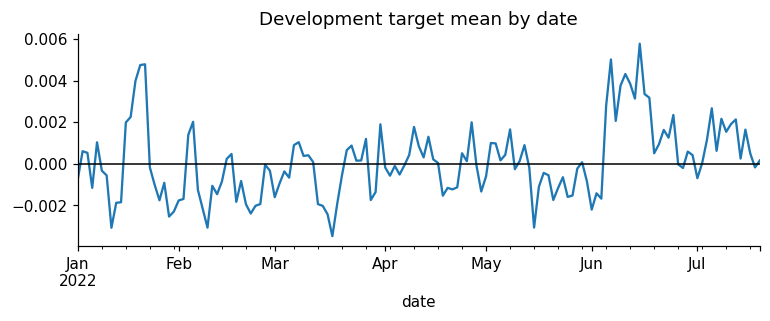

Purged 1 dates; holdout target remains sealed until R12.10.


In [5]:
train_panel, test_panel = (panel[panel["_split"].eq(split)].copy() for split in ("train", "test"))
train_dates = np.array(sorted(train_panel[TIME_COL].unique()))
n_holdout = max(1, int(np.ceil(len(train_dates) * FINAL_HOLDOUT_FRACTION)))
holdout_dates = train_dates[-n_holdout:]; purged_dates = train_dates[-n_holdout - PURGE_DATES:-n_holdout]
development_dates = train_dates[:-n_holdout - PURGE_DATES]
development = train_panel[train_panel[TIME_COL].isin(development_dates)].copy()
final_holdout = train_panel[train_panel[TIME_COL].isin(holdout_dates)].copy()
assert development[TIME_COL].max() < final_holdout[TIME_COL].min()
key_duplicates = int(train_panel.duplicated([TIME_COL, ENTITY_COL]).sum())
coverage = development.groupby(TIME_COL, observed=True)[ENTITY_COL].nunique()
missing_rate = development.isna().mean().sort_values(ascending=False).to_frame("missing_rate")
target_by_date = development.groupby(TIME_COL)[TARGET_COL].agg(["count", "mean", "std"])
target_by_date["period"] = pd.qcut(np.arange(len(target_by_date)), 3, labels=["early", "middle", "late"])
target_stability = target_by_date.groupby("period", observed=True).agg(
    dates=("count", "size"), observations=("count", "sum"),
    target_mean=("mean", "mean"), mean_daily_std=("std", "mean"))
audit = pd.Series({"duplicate time-entity keys": key_duplicates,
    "infinite numeric values": int(np.isinf(development.select_dtypes("number").to_numpy()).sum()),
    "development rows/dates": f"{len(development)}/{len(development_dates)}",
    "min/max entities per date": f"{coverage.min()}/{coverage.max()}",
    "sealed holdout rows/dates": f"{len(final_holdout)}/{n_holdout}"})
display(audit.to_frame("value")); display(missing_rate.head(8).round(3)); display(target_stability.round(5))
target_by_date["mean"].plot(figsize=(8, 2.5), title="Development target mean by date")
plt.axhline(0, color="black", lw=1); plt.show()
print(f"Purged {len(purged_dates)} dates; holdout target remains sealed until R12.10.")


## R12.3 · Build only features available at the forecast origin
<a id="r12-3"></a>

**Topic** Feature engineering

**Use when** rows repeat by entity and lag or rolling operations could cross entity boundaries.

**Inputs** panel, ROLL_WINDOWS and the two availability switches.

**Needs** R12.2 — run that first.

**Gotchas** rolling statistics shift once before opening the window. Same-date ranks require the complete date batch. Target history is never derived by shifting hidden test labels: enabling it requires a supplied released_target_lag column with observations in both splits.

**See also** [R12.4](#r12-4) (feature roles) · [R12.6](#r12-6) (lag baselines)


In [6]:
def build_causal_features(frame):
    out = frame.sort_values([ENTITY_COL, TIME_COL]).copy(); grouped = out.groupby(ENTITY_COL, observed=True, sort=False)
    out["observable_lag"], out["ret_lag1"], out["micro_lag1"] = out["ret_1d"], grouped["ret_1d"].shift(1), grouped["micro_signal"].shift(1)
    for window in ROLL_WINDOWS:
        minimum = max(2, window // 3)
        out[f"ret_mean_{window}"] = grouped["ret_1d"].transform(
            lambda values: values.shift(1).rolling(window, min_periods=minimum).mean())
        out[f"ret_std_{window}"] = grouped["ret_1d"].transform(
            lambda values: values.shift(1).rolling(window, min_periods=minimum).std())
    out["log_volume"] = np.log1p(out["volume"])
    if TARGET_HISTORY_AVAILABLE:
        column = "released_target_lag"
        supplied = column in out and out.groupby("_split")[column].apply(lambda values: values.notna().any()).all()
        if not supplied:
            raise ValueError("TARGET_HISTORY_AVAILABLE=True requires released_target_lag in train and test")
    if ENABLE_SAME_DATE_CROSS_SECTION:
        date_group = out.groupby(TIME_COL, observed=True)
        out["ret_xs_demean"] = out["ret_1d"] - date_group["ret_1d"].transform("mean")
        out["micro_xs_rank"] = date_group["micro_signal"].rank(pct=True)
    return out.sort_values([TIME_COL, ENTITY_COL]).reset_index(drop=True)
panel = build_causal_features(panel)
train_panel, test_panel = panel[panel["_split"].eq("train")].copy(), panel[panel["_split"].eq("test")].copy()
development = train_panel[train_panel[TIME_COL].isin(development_dates)].reset_index(drop=True)
final_holdout = train_panel[train_panel[TIME_COL].isin(holdout_dates)].reset_index(drop=True)
print([column for column in panel if column.startswith(("ret_lag", "ret_mean", "ret_std", "micro_lag"))]); print(f"same-date cross-section: {ENABLE_SAME_DATE_CROSS_SECTION}; target history: {TARGET_HISTORY_AVAILABLE}")


['ret_lag1', 'micro_lag1', 'ret_mean_5', 'ret_std_5', 'ret_mean_20', 'ret_std_20']
same-date cross-section: False; target history: False


## R12.4 · Declare roles and inspect the final design
<a id="r12-4"></a>

**Topic** Preprocessing

**Use when** the feature builder is complete and before any cross-validation.

**Inputs** development and test_panel after R12.3.

**Needs** R12.3 — run that first.

**Gotchas** standardized mean shift is a triage statistic, not proof of harmful drift. Investigate large values and missingness changes; do not transform the test set to resemble train.

**See also** [R12.1](#r12-1) (join coverage) · [R12.5](#r12-5) (fold geometry)


In [7]:
base_numeric = ["ret_1d", "micro_signal", "beta", "macro_signal",
    "vol_index", "macro_age_days", "log_volume", "ret_lag1", "micro_lag1",
    *[f"ret_mean_{window}" for window in ROLL_WINDOWS],
    *[f"ret_std_{window}" for window in ROLL_WINDOWS]]
xs_numeric = ["ret_xs_demean", "micro_xs_rank"] if ENABLE_SAME_DATE_CROSS_SECTION else []
numeric_features = base_numeric + xs_numeric
if TARGET_HISTORY_AVAILABLE:
    numeric_features.append("released_target_lag")
categorical_features = [GROUP_COL]; feature_columns = numeric_features + categorical_features
for forbidden in (*ID_COLS, ENTITY_COL, TIME_COL, TARGET_COL):
    assert forbidden not in feature_columns
reference, current = development[numeric_features], test_panel[numeric_features]
scale = reference.std().replace(0, np.nan)
drift = pd.DataFrame({"feature": numeric_features,
    "standardized_mean_shift": ((current.mean() - reference.mean()) / scale).to_numpy(),
    "train_null_rate": reference.isna().mean().to_numpy(),
    "test_null_rate": current.isna().mean().to_numpy()})
drift["null_rate_delta"] = drift["test_null_rate"] - drift["train_null_rate"]
known_groups = set(development[GROUP_COL].dropna()); unseen_group_rate = float((~test_panel[GROUP_COL].isin(known_groups)).mean())
order = drift["standardized_mean_shift"].abs().sort_values(ascending=False).index
display(drift.loc[order].head(8).round(3))
print({"features": len(feature_columns),
    "high_card_ids_excluded": not set((*ID_COLS, ENTITY_COL)) & set(feature_columns),
    "unseen_test_group_rate": unseen_group_rate,
    "same_date_features_enabled": ENABLE_SAME_DATE_CROSS_SECTION})


,feature,standardized_mean_shift,train_null_rate,test_null_rate,null_rate_delta
4,vol_index,1.505,0.000,0.0,0.000
10,ret_mean_20,0.681,0.043,0.0,-0.043
3,macro_signal,0.645,0.000,0.0,0.000
12,ret_std_20,0.552,0.043,0.0,-0.043
9,ret_mean_5,0.351,0.014,0.0,-0.014
0,ret_1d,0.220,0.000,0.0,0.000
11,ret_std_5,0.217,0.014,0.0,-0.014
7,ret_lag1,0.205,0.007,0.0,-0.007


{'features': 14, 'high_card_ids_excluded': True, 'unseen_test_group_rate': 0.0, 'same_date_features_enabled': False}


## R12.5 · Split unique dates forward and purge the label horizon
<a id="r12-5"></a>

**Topic** Cross-validation

**Use when** many entities share each timestamp and the label looks forward.

**Inputs** development, N_SPLITS and PURGE_DATES.

**Needs** R12.4 — run that first.

**Gotchas** sklearn splits the unique-date array here, then dates map back to rows. Calling TimeSeriesSplit directly on panel rows would split inside a date and leak common market information.

**See also** [R12.2](#r12-2) (sealed holdout) · [R12.8](#r12-8) (same folds for every candidate)


In [8]:
def make_panel_splits(frame):
    dates = np.array(sorted(frame[DATE_COL].unique()))
    raw_splits = TimeSeriesSplit(n_splits=N_SPLITS).split(dates)
    for fit_date_index, valid_date_index in raw_splits:
        if PURGE_DATES:
            fit_date_index = fit_date_index[:-PURGE_DATES]
        fit_dates, valid_dates = dates[fit_date_index], dates[valid_date_index]
        fit_rows = np.flatnonzero(frame[DATE_COL].isin(fit_dates).to_numpy())
        valid_rows = np.flatnonzero(frame[DATE_COL].isin(valid_dates).to_numpy())
        yield fit_rows, valid_rows, fit_dates, valid_dates

splits = list(make_panel_splits(development))
all_development_dates = np.array(sorted(development[DATE_COL].unique()))
fold_rows = []
for fold, (fit_rows, valid_rows, fit_dates, valid_dates) in enumerate(splits):
    train_end = np.searchsorted(all_development_dates, fit_dates[-1])
    valid_start = np.searchsorted(all_development_dates, valid_dates[0])
    realized_gap = int(valid_start - train_end - 1)
    assert fit_dates[-1] < valid_dates[0] and realized_gap >= PURGE_DATES
    fold_rows.append({
        "fold": fold, "train_rows": len(fit_rows), "valid_rows": len(valid_rows),
        "train_end": fit_dates[-1], "valid_start": valid_dates[0],
        "purged_dates": realized_gap,
    })
fold_table = pd.DataFrame(fold_rows)
fold_table


,fold,train_rows,valid_rows,train_end,valid_start,purged_dates
0,0,1412,1311,2022-02-11,2022-02-15,1
1,1,2723,1323,2022-03-23,2022-03-25,1
2,2,4046,1324,2022-05-02,2022-05-04,1
3,3,5370,1316,2022-06-09,2022-06-13,1


## R12.6 · Make simple forecasts obey the folds
<a id="r12-6"></a>

**Topic** Baselines

**Use when** defining what a learned model must beat.

**Inputs** development and splits.

**Needs** R12.5 — run that first.

**Gotchas** global and sector means are fitted from each fold's training labels. An unseen sector falls back to that fold's global mean. The observable lag is the latest known return; the target-history baseline appears only for an externally supplied released_target_lag column.

**See also** [R12.3](#r12-3) (availability gates) · [R12.8](#r12-8) (honest selection)


In [9]:
BASELINE_NAMES = ["baseline_global", "baseline_group_mean", "baseline_observable_lag"]
if TARGET_HISTORY_AVAILABLE:
    BASELINE_NAMES.append("baseline_released_target_lag")

def predict_baseline(name, fit_frame, score_frame):
    fallback = float(fit_frame[TARGET_COL].mean())
    if name == "baseline_global":
        return np.full(len(score_frame), fallback)
    if name == "baseline_group_mean":
        mapping = fit_frame.groupby(GROUP_COL, observed=True)[TARGET_COL].mean()
        return score_frame[GROUP_COL].map(mapping).fillna(fallback).to_numpy()
    source = "observable_lag" if name == "baseline_observable_lag" else "released_target_lag"
    return pd.to_numeric(score_frame[source], errors="coerce").fillna(fallback).to_numpy()
parts = []
for fold, (fit_rows, valid_rows, _, _) in enumerate(splits):
    fit_frame, valid_frame = development.iloc[fit_rows], development.iloc[valid_rows]
    part = valid_frame[[*ID_COLS, TIME_COL, ENTITY_COL, GROUP_COL, TARGET_COL]].copy()
    part["row_position"], part["fold"] = valid_rows, fold
    for name in BASELINE_NAMES:
        part[name] = predict_baseline(name, fit_frame, valid_frame)
    known = set(fit_frame[GROUP_COL].dropna())
    part["group_fallback"] = ~valid_frame[GROUP_COL].isin(known).to_numpy()
    parts.append(part)
oof = pd.concat(parts, ignore_index=True).sort_values(["fold", TIME_COL, ENTITY_COL])
display(oof.groupby("fold")[[*BASELINE_NAMES, TARGET_COL]].mean().round(5))
print(f"group-mean fallback used on {oof['group_fallback'].mean():.2%} of OOF rows")


,baseline_global,baseline_group_mean,baseline_observable_lag,target
fold,,,,
0,-0.00023,-0.00022,-0.00078,-0.00079
1,-0.00052,-0.00052,0.00003,0.00001
2,-0.00036,-0.00036,-0.00001,0.00013
3,-0.00027,-0.00027,0.00159,0.00145


group-mean fallback used on 0.00% of OOF rows


## R12.7 · Build LightGBM or the clearly labeled sklearn fallback
<a id="r12-7"></a>

**Topic** Pipelines

**Use when** numeric and categorical columns contain missing or unseen values.

**Inputs** numeric_features, categorical_features and feature_columns.

**Needs** R12.6 — run that first.

**Gotchas** both candidates receive the same fold-local imputation and encoding. Set FORCE_SKLEARN_BOOSTER=True to test the explicit HistGradientBoostingRegressor fallback. Always report the printed booster label rather than calling both implementations LightGBM.

**See also** [R12.4](#r12-4) (declared roles) · [R12.8](#r12-8) (OOF comparison)


In [10]:
numeric_branch = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())])
category_branch = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocess = ColumnTransformer([("numeric", numeric_branch, numeric_features), ("category", category_branch, categorical_features)])
ridge = Ridge(alpha=10.0); Booster = None
if not FORCE_SKLEARN_BOOSTER:
    try:
        from lightgbm import LGBMRegressor as Booster
    except ImportError:
        pass
if Booster is None:
    boosted_name = "hist_gradient_boosting_fallback"
    boosted = HistGradientBoostingRegressor(max_iter=180, learning_rate=0.05,
        max_leaf_nodes=15, l2_regularization=1.0, random_state=SEED)
else:
    boosted_name = "lightgbm"
    boosted = Booster(n_estimators=180, learning_rate=0.04, num_leaves=15,
        min_child_samples=30, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=SEED, n_jobs=N_JOBS, verbosity=-1, deterministic=True, force_col_wise=True)
model_pipelines = {
    "ridge": Pipeline([("prepare", clone(preprocess)), ("model", ridge)]),
    boosted_name: Pipeline([("prepare", clone(preprocess)), ("model", boosted)])}
active_booster_label = "HIST GRADIENT BOOSTING FALLBACK" if Booster is None else "LIGHTGBM"
print(f"ACTIVE BOOSTER: {active_booster_label}")
print({"forced_sklearn_fallback": FORCE_SKLEARN_BOOSTER, "features": len(feature_columns)})


ACTIVE BOOSTER: LIGHTGBM
{'forced_sklearn_fallback': False, 'features': 14}


## R12.8 · Compare every candidate on one OOF ledger
<a id="r12-8"></a>

**Topic** Model selection

**Use when** choosing the final forecasting rule.

**Inputs** oof, splits and model_pipelines.

**Needs** R12.7 — run that first.

**Gotchas** RMSE alone selects the candidate. MAE and mean within-date rank IC describe different behavior but cannot silently replace the declared objective. Baselines remain eligible to win.

**See also** [R12.6](#r12-6) (fold-local baselines) · [R12.9](#r12-9) (diagnostics)


In [11]:
for name, pipeline in model_pipelines.items():
    predictions = np.full(len(development), np.nan)
    for fit_rows, valid_rows, _, _ in splits:
        fitted = clone(pipeline).fit(development.iloc[fit_rows][feature_columns],
                                     development.iloc[fit_rows][TARGET_COL])
        predictions[valid_rows] = fitted.predict(development.iloc[valid_rows][feature_columns])
    oof[name] = predictions[oof["row_position"].to_numpy()]
candidate_names = BASELINE_NAMES + list(model_pipelines); expected_rows = np.concatenate([valid_rows for _, valid_rows, _, _ in splits])
assert oof[ROW_ID_COL].is_unique, "each source ID must appear in OOF at most once"
assert oof["row_position"].is_unique, "each source position must appear in OOF at most once"
assert len(oof) == len(expected_rows), "OOF row count changed"
assert set(oof["row_position"]) == set(expected_rows), "OOF row coverage changed"
assert oof[candidate_names].notna().all().all(), "all candidates must score the same rows"
score_rows = [{"candidate": name, "rmse": rmse(oof[TARGET_COL], oof[name]),
    "mae": mean_absolute_error(oof[TARGET_COL], oof[name]),
    "mean_date_rank_ic": rank_ic_by_date(oof, oof[name]).mean()} for name in candidate_names]
score_table = pd.DataFrame(score_rows).sort_values("rmse").reset_index(drop=True)
best_baseline_rmse = score_table.loc[
    score_table["candidate"].isin(BASELINE_NAMES), "rmse"].min()
score_table["rmse_improvement_vs_best_baseline"] = 1 - score_table["rmse"] / best_baseline_rmse
selection_name = str(score_table.iloc[0]["candidate"])
selection_lock = {"candidate": selection_name, "metric": "OOF RMSE",
    "features": tuple(feature_columns), "same_date_cross_section": ENABLE_SAME_DATE_CROSS_SECTION,
    "target_history_available": TARGET_HISTORY_AVAILABLE}
display(score_table.round(5)); print("locked before final holdout:", selection_lock)


,candidate,rmse,mae,mean_date_rank_ic,rmse_improvement_vs_best_baseline
0,ridge,0.00609,0.00483,0.47349,0.13663
1,lightgbm,0.00619,0.00494,0.44996,0.12218
2,baseline_group_mean,0.00705,0.00567,0.12500,0.00000
3,baseline_global,0.00710,0.00571,NaN,-0.00727
4,baseline_observable_lag,0.00873,0.00699,0.20266,-0.23792


locked before final holdout: {'candidate': 'ridge', 'metric': 'OOF RMSE', 'features': ('ret_1d', 'micro_signal', 'beta', 'macro_signal', 'vol_index', 'macro_age_days', 'log_volume', 'ret_lag1', 'micro_lag1', 'ret_mean_5', 'ret_mean_20', 'ret_std_5', 'ret_std_20', 'sector'), 'same_date_cross_section': False, 'target_history_available': False}


## R12.9 · Diagnose the out-of-fold errors as a panel
<a id="r12-9"></a>

**Topic** Diagnostics

**Use when** the OOF winner is locked but before opening the final holdout.

**Inputs** oof and selection_name.

**Needs** R12.8 — run that first.

**Gotchas** pooled residuals can hide one bad date, sector or entity. Rank IC is computed within date, and residual autocorrelation is computed within entity, so neither diagnostic crosses panel boundaries. Always show counts beside sliced errors.

**See also** [R12.2](#r12-2) (initial audit) · [R12.10](#r12-10) (final evidence)


,n,mae,rmse
fold,,,
0,1311,0.00468,0.00600
1,1323,0.00492,0.00622
2,1324,0.00488,0.00602
3,1316,0.00484,0.00610


,n,mae,bias
sector,,,
technology,885,0.00495,0.00020
health,879,0.00490,0.00018
financials,874,0.00490,0.00045
energy,876,0.00482,-0.00026
utilities,880,0.00472,0.00001
industrial,880,0.00468,0.00030


,n,mae,bias
asset_id,,,
A041,110,0.00560,0.00129
A010,112,0.00550,-0.00131
A044,112,0.00541,0.00066
A000,111,0.00531,-0.00145
A034,110,0.00529,0.00038
A037,111,0.00521,0.00001
A031,109,0.00516,0.00089
A038,111,0.00513,-0.00025


mean within-entity residual lag-1 correlation: -0.023


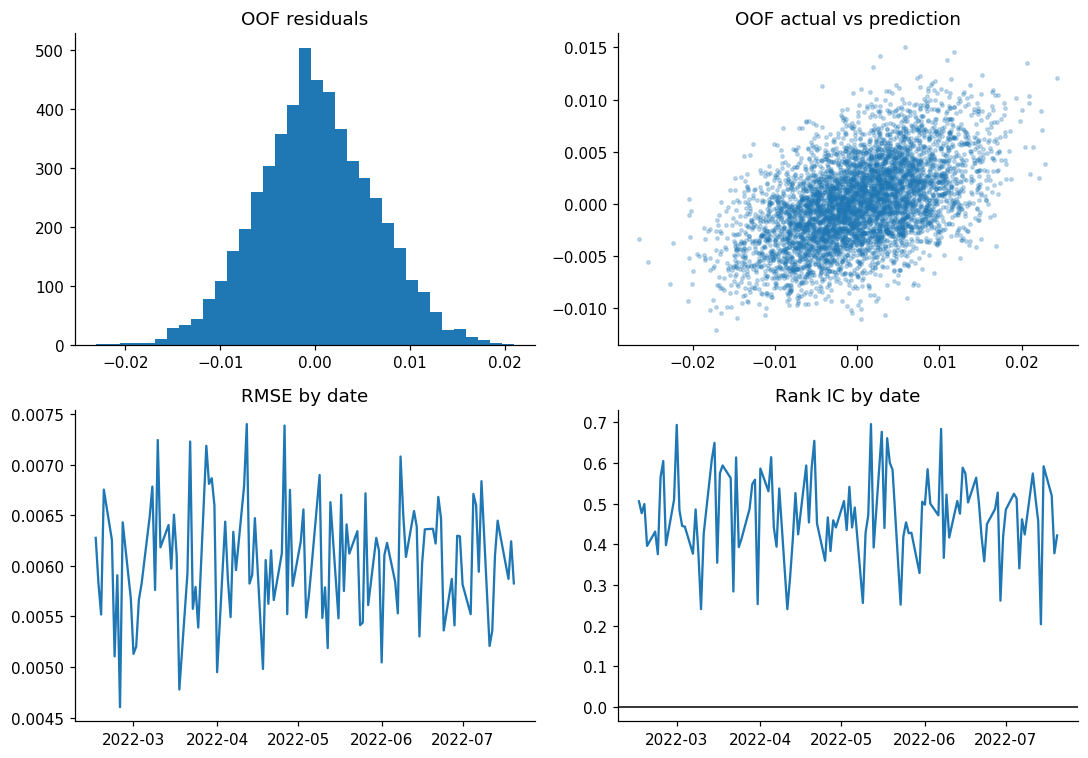

In [12]:
chosen = oof[[*ID_COLS, TIME_COL, ENTITY_COL, GROUP_COL, TARGET_COL, "fold", selection_name]].copy()
chosen["residual"] = chosen[TARGET_COL] - chosen[selection_name]
chosen["absolute_error"], chosen["squared_error"] = chosen["residual"].abs(), chosen["residual"].pow(2)
fold_diagnostic = chosen.groupby("fold").agg(n=(TARGET_COL, "size"), mae=("absolute_error", "mean"), mse=("squared_error", "mean"))
fold_diagnostic["rmse"] = np.sqrt(fold_diagnostic.pop("mse"))
date_diagnostic = chosen.groupby(TIME_COL).agg(n=(TARGET_COL, "size"), mae=("absolute_error", "mean"), mse=("squared_error", "mean"))
date_diagnostic["rmse"] = np.sqrt(date_diagnostic.pop("mse"))
date_diagnostic["rank_ic"] = rank_ic_by_date(chosen, chosen[selection_name])
group_diagnostic = chosen.groupby(GROUP_COL, observed=True).agg(n=(TARGET_COL, "size"), mae=("absolute_error", "mean"), bias=("residual", "mean")).sort_values("mae", ascending=False)
entity_diagnostic = chosen.groupby(ENTITY_COL, observed=True).agg(n=(TARGET_COL, "size"), mae=("absolute_error", "mean"), bias=("residual", "mean")).sort_values("mae", ascending=False)
entity_rho = chosen.sort_values([ENTITY_COL, TIME_COL]).groupby(ENTITY_COL, observed=True).apply(
    lambda group: group["residual"].corr(group["residual"].shift(1)), include_groups=False)
display(fold_diagnostic.round(5)); display(group_diagnostic.round(5)); display(entity_diagnostic.head(8).round(5))
print(f"mean within-entity residual lag-1 correlation: {entity_rho.mean():+.3f}")
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].hist(chosen["residual"], bins=35); axes[0, 0].set_title("OOF residuals")
axes[0, 1].scatter(chosen[TARGET_COL], chosen[selection_name], s=5, alpha=0.25)
axes[0, 1].set_title("OOF actual vs prediction")
axes[1, 0].plot(date_diagnostic.index, date_diagnostic["rmse"]); axes[1, 0].set_title("RMSE by date")
axes[1, 1].plot(date_diagnostic.index, date_diagnostic["rank_ic"])
axes[1, 1].axhline(0, color="black", lw=1); axes[1, 1].set_title("Rank IC by date")
fig.tight_layout(); plt.show()


## R12.10 · Open once, refit once, align by sample ID
<a id="r12-10"></a>

**Topic** Reporting

**Use when** the OOF decision and diagnostics are complete.

**Inputs** selection_lock, development, final_holdout, train_panel, test_panel and sample_submission.

**Needs** R12.9 — run that first.

**Gotchas** the holdout score is evidence about the locked rule, not another selection round. Submission values are joined onto the sample's IDs so a reordered sample cannot silently misalign predictions.

**See also** [R12.2](#r12-2) (how the holdout was sealed) · [R12.8](#r12-8) (selection lock)


In [13]:
def fit_or_predict(name, fit_frame, score_frame):
    if name in model_pipelines:
        fitted = clone(model_pipelines[name]).fit(
            fit_frame[feature_columns], fit_frame[TARGET_COL])
        return fitted, fitted.predict(score_frame[feature_columns])
    return None, predict_baseline(name, fit_frame, score_frame)
holdout_model, holdout_prediction = fit_or_predict(selection_name, development, final_holdout)
final_holdout_rmse = rmse(final_holdout[TARGET_COL], holdout_prediction)
full_train = train_panel.dropna(subset=[TARGET_COL]).reset_index(drop=True)
final_model, test_prediction = fit_or_predict(selection_name, full_train, test_panel)
prediction_frame = test_panel[[*ID_COLS]].assign(**{PREDICTION_COL: test_prediction})
submission = sample_submission[[*ID_COLS]].merge(
    prediction_frame, on=list(ID_COLS), how="left", validate="one_to_one", sort=False)
assert np.array_equal(submission[[*ID_COLS]].to_numpy(), sample_submission[[*ID_COLS]].to_numpy())
assert len(submission) == len(sample_submission)
assert not submission.duplicated(list(ID_COLS)).any()
assert np.isfinite(submission[PREDICTION_COL]).all()
release_summary = pd.Series({"locked_candidate": selection_name,
    "oof_rmse": float(score_table.iloc[0]["rmse"]),
    "final_holdout_rmse": final_holdout_rmse, "refit_rows": len(full_train),
    "submission_rows": len(submission), "sample_order_preserved": True,
    "baseline_retained": selection_name in BASELINE_NAMES,
    "active_booster": active_booster_label})
display(release_summary.to_frame("value"))
submission.head(3)


,value
locked_candidate,ridge
oof_rmse,0.006086
final_holdout_rmse,0.006016
refit_rows,8469
submission_rows,1407
sample_order_preserved,True
baseline_retained,False
active_booster,LIGHTGBM


,row_id,prediction
0,row_008822,-0.001282
1,row_009333,-0.003838
2,row_009630,0.001956


## Verdict & what carries forward

This notebook leaves one compact, defensible chain of evidence:

data roles and availability → validated many-to-one and backward as-of joins → sealed final dates → causal grouped features → train/test drift → purged unique-date folds → fold-local baselines → Ridge and boosted-tree pipelines → one OOF ledger → panel-aware diagnostics → locked holdout → refit and sample-aligned submission.

The important result is not that a particular algorithm wins the synthetic fixture. It is that every candidate sees the same validation dates and the same rows, and that a simple baseline remains the final rule when no learned model improves OOF RMSE. In a real interview, finish by stating the largest remaining risk—usually label availability, temporal drift, join timing, or unstable date-level performance—and the single next experiment that addresses it.
